In [55]:
!pip3 install gensim

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 24.1 MB 719 kB/s eta 0:00:01
     |████████████████████████████████| 61 kB 537 kB/s  eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [27]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_hub as hub
import seaborn as sns
import tldextract
import re
import whois
import numpy as np
from datetime import datetime
from urllib.parse import urlparse
from Levenshtein import distance as levenshtein_distance
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## data collection

In [28]:
def fetch_crypto_datasets(url):
    # Make the request
    response = requests.get(url)
    if response.status_code == 200:
        # Return the JSON data
        return response.json() 
    else:
        print(f"Failed to fetch data. Status code: {response.status_code}. Reason: {response.reason}")
        
        return []

In [29]:
datasets_raw = fetch_crypto_datasets("https://raw.githubusercontent.com/seigdev/artificial-intelligence/refs/heads/main/crypto_data.json")

In [30]:
datasets_df = pd.DataFrame(datasets_raw)

## eda

In [31]:
# view the first few rows
datasets_df.head()

,url,label,label_no
0,https://pan-cakev-app.info,scam,1
1,https://harrods.com,legit,0
2,https://claim.dogshouse.store,scam,1
3,https://circle-foundation.com,scam,1
4,https://wepdex.com,scam,1


In [32]:
# basic info
print(datasets_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       150000 non-null  object
 1   label     150000 non-null  object
 2   label_no  150000 non-null  object
dtypes: object(3)
memory usage: 3.4+ MB
None


In [33]:
# count the number of scam and legitimate links
datasets_df["label"].value_counts()

label
scam     100000
legit     50000
Name: count, dtype: int64

In [34]:
# Summary statistics for numerical columns (if any)
print(datasets_df.describe())

                                 url   label label_no
count                         150000  150000   150000
unique                        149670       2        2
top     https://app.uniswap.org/swap    scam        1
freq                              21  100000   100000


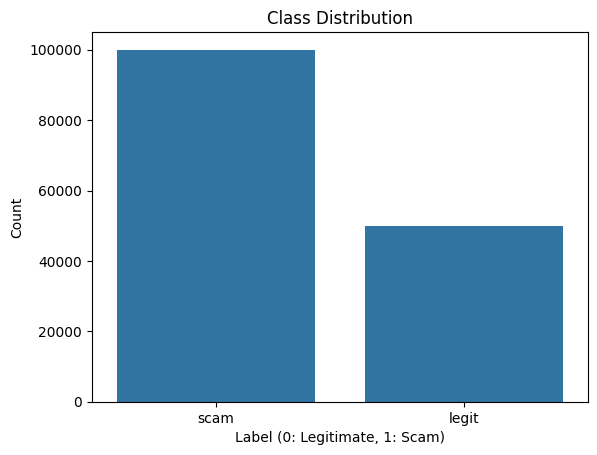

In [35]:
#  count the number of scam and legitimate links
class_distribution = datasets_df["label"].value_counts()

# plot the distribution
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title("Class Distribution")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Count")
plt.show()

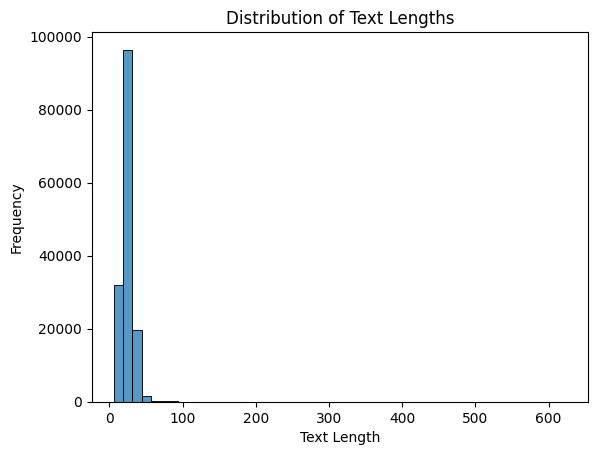

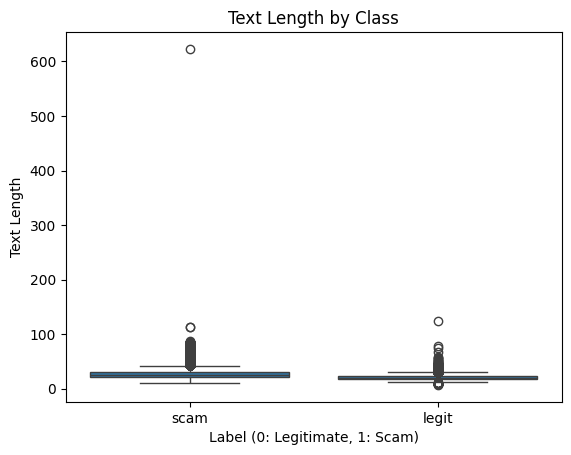

In [36]:
# add a column for text length
datasets_df["url_length"] = datasets_df["url"].apply(len)

# plot the distribution of text lengths
sns.histplot(datasets_df["url_length"], bins=50)
plt.title("Distribution of Text Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

# compare text lengths for scam vs. legitimate links
sns.boxplot(x="label", y="url_length", data=datasets_df)
plt.title("Text Length by Class")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Text Length")
plt.show()

Unique domains: 104164
Top TLDs: tld
com       54542
io        11733
net        8344
xyz        7358
org        6943
app        6152
dev        5684
top        2786
ru         2126
online     2094
Name: count, dtype: int64


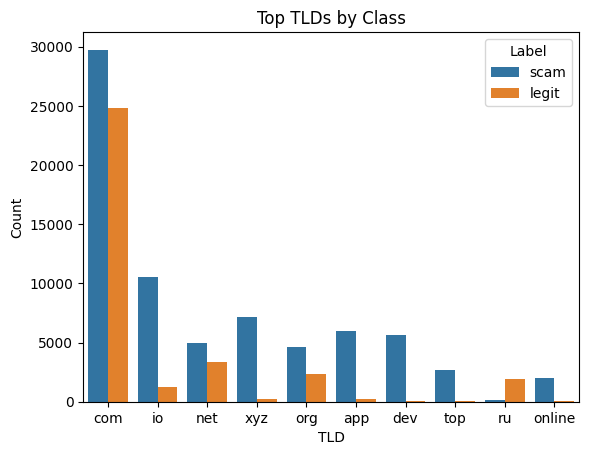

In [37]:
# extract domain and TLD
datasets_df["domain"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).domain)
datasets_df["tld"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).suffix)

# count unique domains and TLDs
print("Unique domains:", datasets_df["domain"].nunique())
print("Top TLDs:", datasets_df["tld"].value_counts().head(10))

# compare TLDs for scam vs. legitimate links
sns.countplot(x="tld", hue="label", data=datasets_df, order=datasets_df["tld"].value_counts().iloc[:10].index)
plt.title("Top TLDs by Class")
plt.xlabel("TLD")
plt.ylabel("Count")
plt.legend(title="Label", loc="upper right")
plt.show()

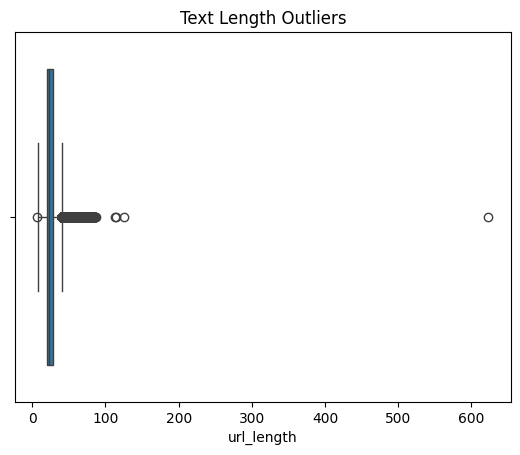

In [38]:
# boxplot for text length
sns.boxplot(x=datasets_df["url_length"])
plt.title("Text Length Outliers")
plt.show()

## preprocessing

In [39]:
# function to process url
def procees_url(url):
    """Extracts features from a URL."""
    
    TECHNICAL_WORDS = {"www", "http", "https"}
                       
    SCAM_KEYWORDS = [
    "free", "giveaway", "bonus", "earn", "profit", "double", "investment", 
    "claim", "win", "lottery", "rich", "money", "wallet", "support", 
    "verification", "login", "secure", "account", "recovery"
]
    
    # Convert to lowercase
    url = url.lower()
    
    # Extract domain, subdomain, and suffix
    extracted = tldextract.extract(url)
    # domain = extracted.domain
    subdomain = extracted.subdomain
    tld = extracted.suffix
    
    # tokenisation (split URL into words based on delimiters)
    tokens = re.split(r"[-._~:/?#\[\]@!$&'()*+,;=]+", url)
    # remove only technical words
    filtered_tokens = [t for t in tokens if t and t not in TECHNICAL_WORDS and t != tld]
    filtered_tokens = " ".join(filtered_tokens)
    
    # Count URL length and number of special characters
    url_length = len(url)
    special_char_count = len(re.findall(r'[.-_/]', url))
    
    # Common suspicious keywords
    keyword_count = sum(1 for token in tokens if token in SCAM_KEYWORDS)
    
    return {
        'subdomain': subdomain,
        'special_char_count': special_char_count,
        'keyword_count': keyword_count,
        "tokenized_tokens": filtered_tokens
    }

def detect_typosquatting(url, legitimate_domains, threshold=2):
    # extract domain from URL
    parsed_url = urlparse(url)
    domain = parsed_url.netloc
    
    # check similarity with legitimate domains
    min_distance = float("inf")
    for legit_domain in legitimate_domains:
        dist = levenshtein_distance(domain, legit_domain)
        if dist < min_distance:
            min_distance = dist
    
    # flag as typosquatting if the minimum distance is below the threshold
    return int(min_distance <= threshold)

def get_domain_age(url):
    try:
        # fetch domain registration details
        domain_info = whois.whois(url)
        
        # extract creation date
        creation_date = domain_info.creation_date
        if isinstance(creation_date, list):
            creation_date = creation_date[0]
        
        # calculate domain age in days
        if creation_date:
            domain_age = (datetime.now() - creation_date).days
        else:
            domain_age = None
    except Exception as e:
        # handle errors (e.g., invalid domain or WHOIS lookup failure)
        domain_age = None
    
    # return -1 if domain age cannot be determined
    return domain_age if domain_age is not None else -1

In [40]:
# process the url
proceesed_df = pd.DataFrame([procees_url(url) for url in datasets_df["url"]])

In [41]:
# fetch legitimate domains
legitimate_domains = datasets_df[datasets_df["label_no"] == 0]

# detect typosquatting
proceesed_df["is_typosquatting"] = datasets_df["url"].apply(detect_typosquatting, legitimate_domains=legitimate_domains)

# fetch domain age
proceesed_df["domain_age"] = datasets_df["url"].apply(get_domain_age)

set(proceesed_df["domain_age"])

{-1}

In [42]:
datasets_df[['subdomain','special_char_count','keyword_count', 'tokenized_tokens']] = proceesed_df[['subdomain','special_char_count','keyword_count', 'tokenized_tokens']] 
datasets_df

,url,label,label_no,url_length,domain,tld,subdomain,special_char_count,keyword_count,tokenized_tokens
0,https://pan-cakev-app.info,scam,1,26,pan-cakev-app,info,,4,0,pan cakev app
1,https://harrods.com,legit,0,19,harrods,com,,4,0,harrods
2,https://claim.dogshouse.store,scam,1,29,dogshouse,store,claim,5,1,claim dogshouse
3,https://circle-foundation.com,scam,1,29,circle-foundation,com,,4,0,circle foundation
4,https://wepdex.com,scam,1,18,wepdex,com,,4,0,wepdex
...,...,...,...,...,...,...,...,...,...,...
149995,https://hualeebaix.fun,scam,1,22,hualeebaix,fun,,4,0,hualeebaix
149996,https://myetnherwallet.com,scam,1,26,myetnherwallet,com,,4,0,myetnherwallet
149997,https://giveawayton.online,scam,1,26,giveawayton,online,,4,0,giveawayton
149998,https://trustwallet-support.tech,scam,1,32,trustwallet-support,tech,,4,1,trustwallet support


## feature engineering

In [43]:
label_map = {0: "legit", 1: "scam"}
label_map

{0: 'legit', 1: 'scam'}

#### tf-idf 
- unigrams, bigrams, and trigrams

In [44]:
# TF-IDF vectorization
# vectorizer = TfidfVectorizer(max_features=5000)
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X_tfidf = vectorizer.fit_transform(datasets_df["tokenized_tokens"]).toarray()

#### nnlm

In [45]:
# using nnlm-50

# load NNLM embeddings (50-dimensional)
embed_50 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

# fetch embeddings of urls
X_embeddings_50 = embed_50(datasets_df["tokenized_tokens"].tolist()).numpy()

X_embeddings_50

2025-03-21 08:29:58.171440: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'sentences' with dtype string and shape [?]
	 [[{{node sentences}}]]


array([[ 0.23955777, -0.13139409, -0.31237373, ...,  0.06770783,
         0.11889604,  0.27045536],
       [ 0.29573312,  0.17079203, -0.03106012, ..., -0.1368583 ,
        -0.1164866 , -0.32729188],
       [ 0.1366454 , -0.04997053,  0.03088268, ...,  0.05547405,
        -0.17536575, -0.1431083 ],
       ...,
       [ 0.28379825, -0.08387568, -0.03067106, ..., -0.21166159,
        -0.2832608 , -0.11248049],
       [ 0.21315642,  0.26510954,  0.06730617, ..., -0.09491085,
         0.17821868,  0.17991823],
       [ 0.32946935,  0.06183252, -0.3679874 , ..., -0.28111735,
         0.07008582,  0.02279709]], dtype=float32)

In [46]:
# using nnlm-128

# load NNLM embeddings (128-dimensional)
embed_128 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

# fetch embeddings of urls
X_embeddings_128 = embed_128(datasets_df["tokenized_tokens"].tolist()).numpy()

X_embeddings_128

2025-03-21 08:29:59.179421: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'sentences' with dtype string and shape [?]
	 [[{{node sentences}}]]


array([[ 0.23955777, -0.13139409, -0.31237373, ...,  0.06770783,
         0.11889604,  0.27045536],
       [ 0.29573312,  0.17079203, -0.03106012, ..., -0.1368583 ,
        -0.1164866 , -0.32729188],
       [ 0.1366454 , -0.04997053,  0.03088268, ...,  0.05547405,
        -0.17536575, -0.1431083 ],
       ...,
       [ 0.28379825, -0.08387568, -0.03067106, ..., -0.21166159,
        -0.2832608 , -0.11248049],
       [ 0.21315642,  0.26510954,  0.06730617, ..., -0.09491085,
         0.17821868,  0.17991823],
       [ 0.32946935,  0.06183252, -0.3679874 , ..., -0.28111735,
         0.07008582,  0.02279709]], dtype=float32)

#### feature engineering continued...

In [47]:
# Combine with URL-specific features
X_combined = np.hstack((X_tfidf, datasets_df[["subdomain","url_length", "special_char_count", "keyword_count"]].values))

In [48]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(X_combined, datasets_df["label"], test_size=0.2, random_state=42)

print("number of tweets in training dataset: ", X_train.shape[0])
print("number of tweets in testing dataset: ", X_test.shape[0])

number of tweets in training dataset:  120000
number of tweets in testing dataset:  30000


## modelling

In [49]:
def get_confusion_metric(model, X_train, y_train, X_test, y_test):
    # train the model on training data
    model.fit(X_train, y_train)
    
    # evaluate the model
    y_pred = model.predict(X_test)

    # calculate the performance metrics
    accuracy = accuracy_score(y_test, y_pred)

    confusion = confusion_matrix(y_test, y_pred)
    

    return accuracy, confusion

def train_model(model_name, model):
    accuracy, confusion = get_confusion_metric(model, X_train, y_train, X_test, y_test)
    print("Model Name:", model_name)
    print("Accuracy: ", accuracy)
    print("Confusion Matrix: ", confusion)
    disp = ConfusionMatrixDisplay(confusion, display_labels = label_map.keys())
    disp.plot()
    plt.show()

In [52]:
lr_model = LogisticRegression(max_iter = 300, multi_class = "multinomial")

# rfc_model = RandomForestClassifier(class_weight="balanced", random_state=42)

In [53]:
# using logisitics regression
train_model("Logistic Regression", lr_model)

# using random forest classifier
# train_model("Random Forest Classifier", rfc_model)

/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


KeyboardInterrupt: 